In [100]:
# code to turn images into feature masks
import numpy as np
from PIL import Image
from pathlib import Path
from scipy.ndimage import median_filter
import os

LABELS = ["field", "field","field", "road", "city", "city", "boundary"]
REF_COLORS = np.array([
    [136, 163,  27],   # field 
    [157, 173,  58], 
    [59, 75,  9],
    [240, 229, 220],   # road 
    [146, 108,  54],   # city
    [227, 176,  95],   
    [0, 0,  0],        # boundary (shouldn't be necessary)
], dtype=float)


def classify_pixels(img_arr):
    """
    img_arr: (H, W, 3) uint8
    returns: (H, W) array of labels
    """
    h, w, _ = img_arr.shape
    pixels = img_arr.reshape(-1, 3).astype(float)

    # Compute squared distances: (N_pixels, N_labels)
    dists = np.sum((pixels[:, None, :] - REF_COLORS[None, :, :]) ** 2, axis=2)

    # Pick closest reference color
    labels_idx = np.argmin(dists, axis=1)

    return np.array(LABELS, dtype=object)[labels_idx].reshape(h, w)


In [130]:

from scipy.ndimage import binary_dilation
from scipy.ndimage import label as nd_label

from collections import Counter

def relabel_small_components(feature_map, min_fraction=0.1):
    total_pixels = feature_map.size
    relabeled = feature_map.copy()
    
    for feature in np.unique(feature_map):
        mask = (feature_map == feature)
        labeled, n = nd_label(mask)
        
        for i in range(1, n+1):
            region = (labeled == i)
            if region.sum() < min_fraction * total_pixels and feature  == 'city':
                # Dilate the region to find neighboring pixels
                relabeled[region] = 'field'

                    
    return relabeled

In [133]:
img_directory = "../assets/img/tiles/"
feature_map_directory = "../assets/img/feature_maps/"

files = [
    f for f in os.listdir(img_directory)
    if os.path.isfile(os.path.join(img_directory, f))
]

for tile_name in files:
    if tile_name[-3:] != 'png':
        continue
    img = Image.open(img_directory + tile_name).convert("RGB")
    img_arr = np.array(img)
    
    feature_map = classify_pixels(img_arr)

    label_to_int = {l: i for i, l in enumerate(LABELS)}
    int_to_label = np.array(LABELS)
    
    int_mask = np.vectorize(label_to_int.get)(feature_map)
    smoothed = median_filter(int_mask, size=15)  
    feature_map_smooth = int_to_label[smoothed]

    int_mask = np.vectorize(label_to_int.get)(feature_map)
    smoothed = median_filter(int_mask, size=15)  
    feature_map_smooth = int_to_label[smoothed]



    if 'monastery' in tile_name:
        feature_map_smooth = np.char.replace(feature_map_smooth, "city", "monastery")

    feature_map_smooth = relabel_small_components(feature_map_smooth, min_fraction=0.1)

    
    COLOR_OUT = {
        "field": (0, 255, 0),
        "road": (200, 150, 100),
        "city": (120, 80, 50),
        "monastery": (255, 165, 0),
        "boundary": (0,0,0)
    }
    
    out = np.zeros_like(img_arr)
    for label, color in COLOR_OUT.items():
        out[feature_map_smooth == label] = color

    Image.fromarray(out).save(feature_map_directory + '_feature_map_' + tile_name)

In [81]:
COLOR_OUT = {
    "field": (0, 255, 0),
    "road": (200, 150, 100),
    "city": (120, 80, 50),
    "boundary": (0,0,0)
}

out = np.zeros_like(img_arr)
for label, color in COLOR_OUT.items():
    out[feature_map_smooth == label] = color

Image.fromarray(out).show()

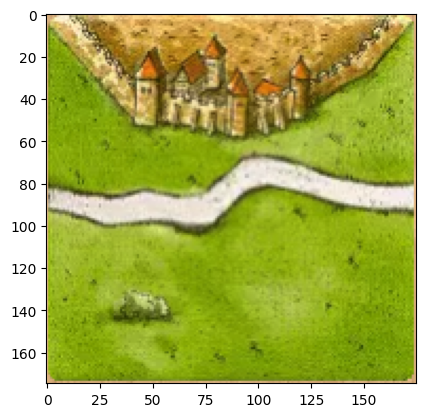

In [43]:
import matplotlib.pyplot as plt
img = Image.open("../assets/img/city_cap_with_straight.png").convert("RGB")
plt.imshow(img)
plt.axis("on")
plt.show()

In [72]:
img_arr = np.array(img)
img_arr[140, 35]

array([59, 75,  9], dtype=uint8)